# Reverse Process Test

In [1]:
import sys, importlib, os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.utils
from typing import Tuple
import yaml
from pathlib import Path
from datetime import datetime
import numpy as np

# Parameters to set

In [52]:
# Set the following parameters
sde_type = "ve"
num_steps = 1000
batch_size = 1

cfg = {
    "sde_type": sde_type,
    "N": num_steps
}

In [37]:
# Importing project packages
cwd = Path(os.getcwd())
root_dir = cwd.parent

utils_dir = root_dir.joinpath('src','utils')
weights_dir = root_dir.joinpath('checkpoints','weights')
model_dir = root_dir.joinpath('src','model')
yaml_file_path = root_dir.joinpath('experiments','base_config.yaml')


# Making packages importable
sys.path.append(str(root_dir))

In [41]:
from src.utils import WIP_SDE, WIP_processes
from src.models import unet_model, components
from src.models import unet_model


importlib.reload(WIP_SDE)
importlib.reload(WIP_processes)
importlib.reload(components)
importlib.reload(unet_model)

UNet = unet_model.UNet
from src.utils.WIP_SDE import VESDE, SubVPSDE
from src.utils.WIP_processes import Diffusion_Processes
from src.models.components import SinusoidalPositionEmbeddings # Required by unet_model
#from src.models.unet_model import UNet

In [53]:
diffusion = Diffusion_Processes(cfg)

In [7]:
import torch
from diffusers import UNet2DModel

# 1. Load Model
model_id = "google/ncsnpp-celebahq-256"
model = UNet2DModel.from_pretrained(model_id)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

An error occurred while trying to fetch google/ncsnpp-celebahq-256: google/ncsnpp-celebahq-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Some weights of the model checkpoint at google/ncsnpp-celebahq-256 were not used when initializing UNet2DModel: 
 ['time_proj.W']


UNet2DModel(
  (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): GaussianFourierProjection()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=256, out_features=512, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=512, out_features=512, bias=True)
  )
  (down_blocks): ModuleList(
    (0-1): 2 x SkipDownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
          (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=512, out_features=128, bias=True)
          (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (resnet_down): ResnetBlock2D(
        (norm1): GroupNorm

In [8]:
# 2. Define the Wrapper (Fixes the TypeError)
def model_fn(x, t):
    # Diffusers expects t to be shape (B,) or a scalar, usually handles it fine.
    with torch.no_grad():
        out = model(x, t)
    
    # Extract the actual tensor from the output object
    if hasattr(out, 'sample'):
        return out.sample
    return out[0]


[reverse step 901/1000 | i=900 | t=0.9000] mean=-7.6875, std=2141.7561, min=-8811.4043, max=9469.0342


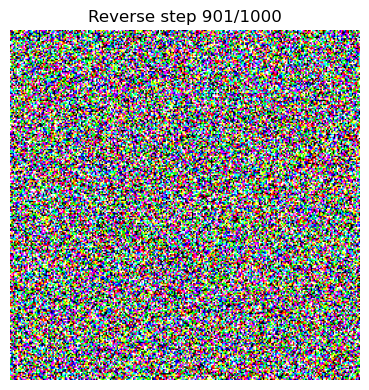

[reverse step 801/1000 | i=800 | t=0.8000] mean=-8.6879, std=2565.7385, min=-10560.6162, max=11353.5361


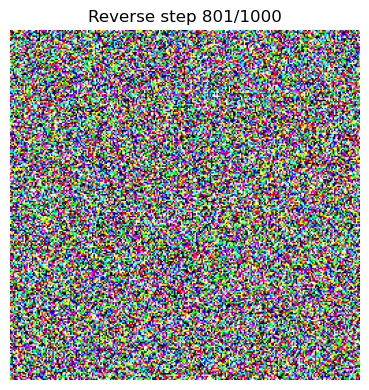

[reverse step 701/1000 | i=700 | t=0.7000] mean=-8.9070, std=2652.9255, min=-10919.3350, max=11740.7793


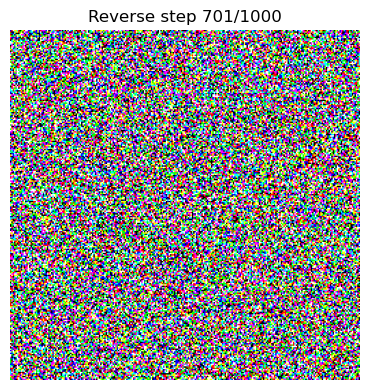

[reverse step 601/1000 | i=600 | t=0.6000] mean=-8.9447, std=2671.1514, min=-10994.5742, max=11818.6611


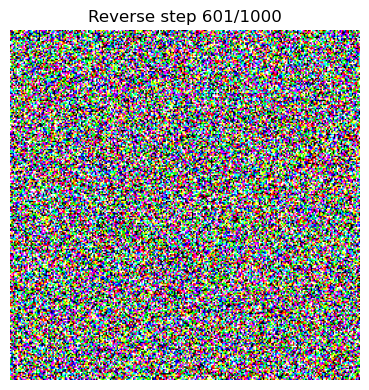

[reverse step 501/1000 | i=500 | t=0.5000] mean=-8.9579, std=2675.0637, min=-11013.3555, max=11835.2637


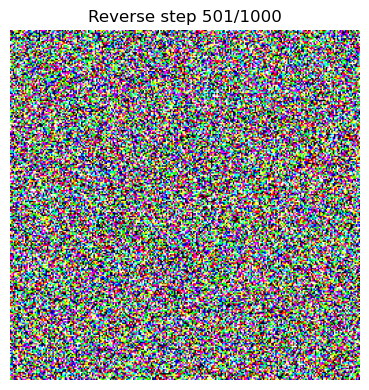

KeyboardInterrupt: 

In [54]:
# 3. Run Sampling (Fixes the AttributeError via the class update)
samples = diffusion.reverse_process(
    model=model_fn,              # Pass the wrapper!
    shape=(batch_size, 3, 256, 256),
    num_steps=cfg.get('N', 1000),
    probability_flow=False,
    device=device                # Pass device explicitly
)

In [ ]:
def show_samples(samples):
    # 1. Ensure we are on CPU
    samples_vis = samples.detach().cpu()
    
    # 2. Inspect statistics (Crucial for debugging!)
    print(f"Sample stats: Min={samples_vis.min():.2f}, Max={samples_vis.max():.2f}, Mean={samples_vis.mean():.2f}")
    
    # 3. Robust Normalization
    # SDE models often output values outside [-1, 1] before the final step.
    # If strict [-1, 1] is expected:
    samples_vis = samples_vis.clamp(-1.0, 1.0)
    samples_vis = (samples_vis + 1.0) / 2.0
    
    # 4. Create Grid
    # nrow=int(np.sqrt(batch_size)) automatically makes a square grid
    grid = torchvision.utils.make_grid(samples_vis, nrow=int(np.sqrt(samples_vis.shape[0])), padding=2)
    
    # 5. Permute for Matplotlib
    np_grid = grid.permute(1, 2, 0).numpy()
    
    # 6. Plot
    plt.figure(figsize=(10, 10))
    plt.imshow(np_grid)
    plt.axis("off")
    plt.title("Generated Samples")
    plt.tight_layout()
    plt.show()

# Run the visualization
show_samples(samples)